# Exploratory Data Analysis (EDA)
**Goal**: Understand the distribution of toxic labels, text characteristics, and label correlations.

In [3]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

sys.path.append(os.path.abspath('../'))
from src.data.loader import load_processed_data
from src.features.preprocessing import clean_text

# Set plotting style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Data

In [4]:
df, label_cols = load_processed_data("../data/raw/youtoxic_english_1000.csv")
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (1000, 13)


,Text,IsToxic,IsAbusive,IsThreat,IsProvocative,IsObscene,IsHatespeech,IsRacist,IsNationalist,IsSexist,IsHomophobic,IsReligiousHate,IsRadicalism
0,If only people would just take a step back and...,0,0,0,0,0,0,0,0,0,0,0,0
1,Law enforcement is not trained to shoot to app...,1,1,0,0,0,0,0,0,0,0,0,0
2,\nDont you reckon them 'black lives matter' ba...,1,1,0,0,1,0,0,0,0,0,0,0
3,There are a very large number of people who do...,0,0,0,0,0,0,0,0,0,0,0,0
4,"The Arab dude is absolutely right, he should h...",0,0,0,0,0,0,0,0,0,0,0,0


## 2. Label Distribution Analysis
**Objective**: Visualize how many positive (1) vs negative (0) samples exist for each category.

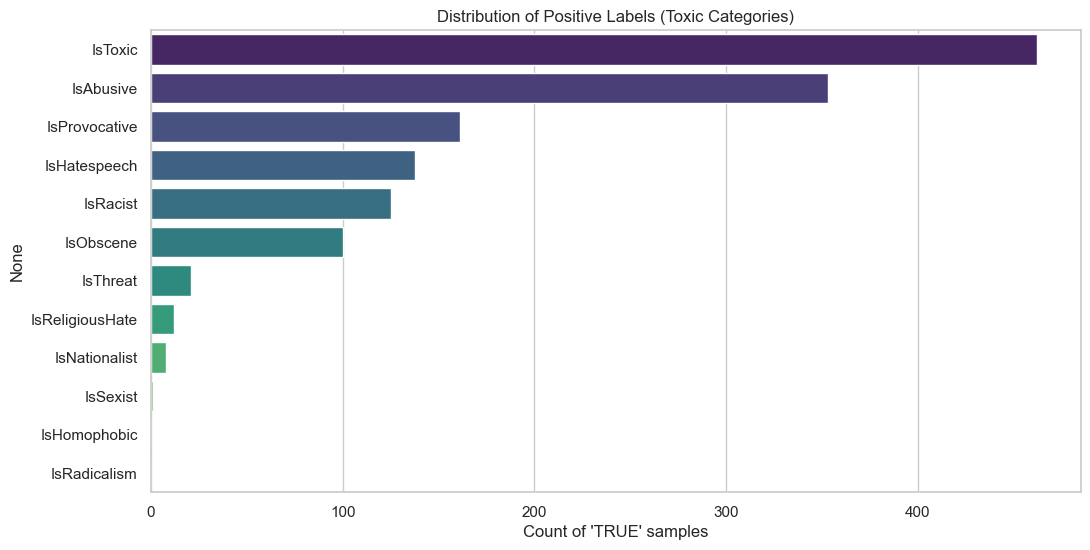

Percentage of Positive Labels:
IsToxic            46.2
IsAbusive          35.3
IsProvocative      16.1
IsHatespeech       13.8
IsRacist           12.5
IsObscene          10.0
IsThreat            2.1
IsReligiousHate     1.2
IsNationalist       0.8
IsSexist            0.1
IsHomophobic        0.0
IsRadicalism        0.0
dtype: float64


In [5]:
label_counts = df[label_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=label_counts.values, y=label_counts.index, hue=label_counts.index, palette='viridis', legend=False)
plt.title("Distribution of Positive Labels (Toxic Categories)")
plt.xlabel("Count of 'TRUE' samples")
plt.show()

# Print exact percentages
print("Percentage of Positive Labels:")
print((df[label_cols].mean() * 100).sort_values(ascending=False))


## 3. Multi-label Analysis
**Objective**: See how many labels are typically assigned to a single comment.

/var/folders/34/cxqx0_l51d59z3f3r64jss700000gn/T/ipykernel_3793/690887280.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=multi_label_counts.index, y=multi_label_counts.values, palette='magma')


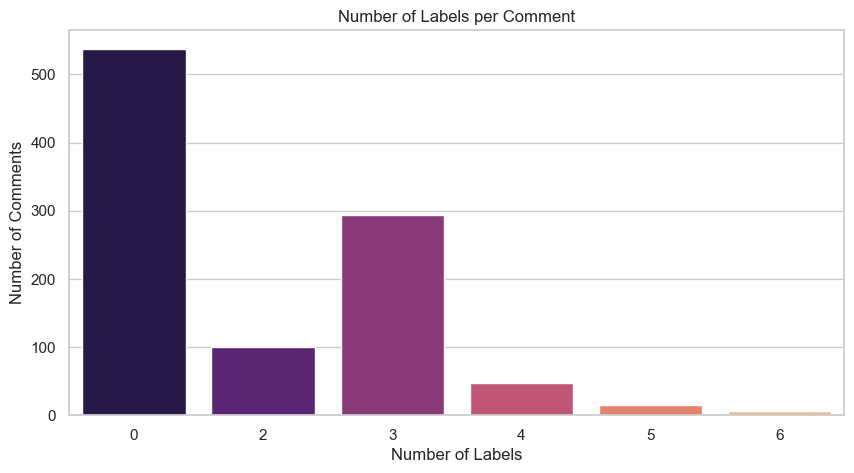

In [6]:
row_sums = df[label_cols].sum(axis=1)
multi_label_counts = row_sums.value_counts().sort_index()

plt.figure(figsize=(10, 5))
sns.barplot(x=multi_label_counts.index, y=multi_label_counts.values, palette='magma')
plt.title("Number of Labels per Comment")
plt.xlabel("Number of Labels")
plt.ylabel("Number of Comments")
plt.show()

## 4. Label Correlation Matrix
**Objective**: Understand which toxic categories often appear together.

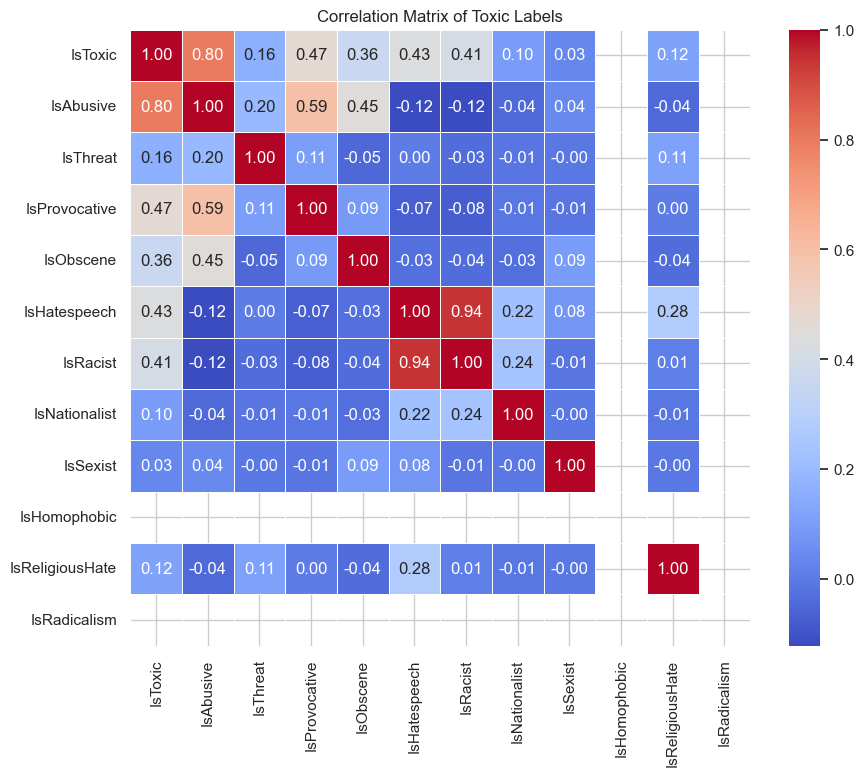

In [7]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[label_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Toxic Labels")
plt.show()

## 5. Text Length Analysis
**Objective**: Compare the length of 'Toxic' vs 'Non-Toxic' comments.

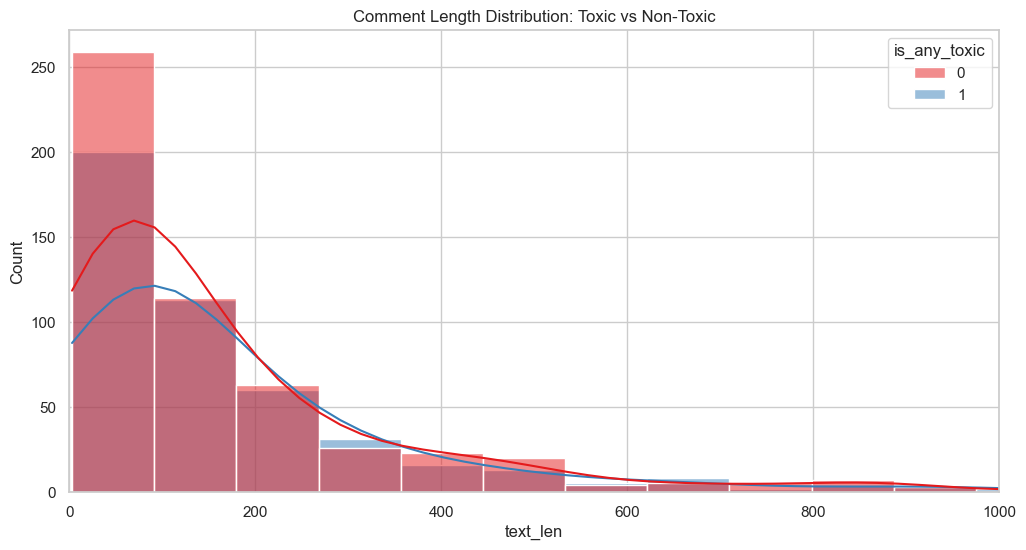

In [8]:
df['text_len'] = df['Text'].apply(len)
df['is_any_toxic'] = (df[label_cols].sum(axis=1) > 0).astype(int)

plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='text_len', hue='is_any_toxic', kde=True, bins=50, palette='Set1')
plt.title("Comment Length Distribution: Toxic vs Non-Toxic")
plt.xlim(0, 1000) # Limiting for better visibility
plt.show()

## 6. Word Cloud Visualization
**Objective**: Visual comparison of frequently used words.

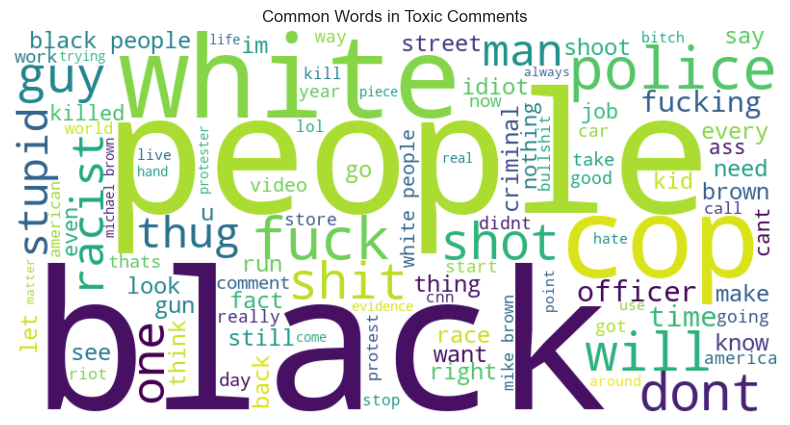

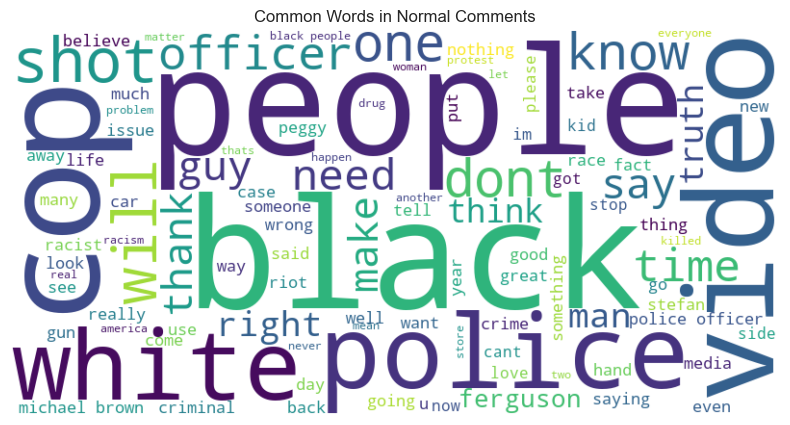

In [9]:
def generate_wordcloud(text, title):
    wc = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

# Clean text for WordCloud
df['CleanText'] = df['Text'].apply(clean_text)

toxic_text = " ".join(df[df['is_any_toxic'] == 1]['CleanText'])
normal_text = " ".join(df[df['is_any_toxic'] == 0]['CleanText'])

generate_wordcloud(toxic_text, "Common Words in Toxic Comments")
generate_wordcloud(normal_text, "Common Words in Normal Comments")